# 01 - Módulo de riesgo: aplicación práctica

Objetivo: descargar 5 activos/fondos/carteras con al menos 10 años de histórico diario, calcular la tabla resumen de métricas de `quantmgmt.risk`, generar los gráficos pedidos y responder a las preguntas de la práctica.

## 0. Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from quantmgmt.data import download_prices
from quantmgmt import risk

PERIODS_PER_YEAR = 252

# TODO: elegir 5 activos/fondos/carteras con >= 10 anios de historico diario
TICKERS = ["SPY", "AGG", "GLD", "VNQ", "EEM"]
START = "2013-01-01"
END = None

## 1. Descarga de datos

In [10]:
prices = download_prices(TICKERS, start=START, end=END)
prices.tail()

Ticker,AGG,EEM,GLD,SPY,VNQ
Date,,,,,
2026-09-23,95.410004,67.709999,392.880005,767.809998,91.449997
2026-09-24,94.949997,67.250000,391.690002,767.179993,91.169998
2026-09-25,95.120003,67.980003,393.410004,771.349976,90.989998
2026-09-28,94.650002,67.199997,377.910004,765.609985,90.589996
2026-09-29,94.599998,67.400002,382.890015,764.200012,90.529999


In [11]:
returns = risk.to_returns(prices, method="log")
returns.tail()

Ticker,AGG,EEM,GLD,SPY,VNQ
Date,,,,,
2026-09-23,-0.008766,-0.020321,-0.018135,-0.007228,-0.014816
2026-09-24,-0.004833,-0.006817,-0.003034,-0.000821,-0.003066
2026-09-25,0.001789,0.010797,0.004382,0.005421,-0.001976
2026-09-28,-0.004953,-0.011540,-0.040196,-0.007469,-0.004406
2026-09-29,-0.000528,0.002972,0.013092,-0.001843,-0.000663


## 2. Tabla resumen de métricas

In [ ]:
# TODO: montar la tabla resumen una vez implementadas las funciones de quantmgmt.risk
summary = pd.DataFrame({
    "CAGR": risk.cagr(returns, PERIODS_PER_YEAR),
    "Rentabilidad anualizada": risk.annualized_return(returns, PERIODS_PER_YEAR),
    "Volatilidad anualizada": risk.annualized_volatility(returns, PERIODS_PER_YEAR),
    "Downside deviation": risk.downside_deviation(returns, periods_per_year=PERIODS_PER_YEAR),
    "Max Drawdown": risk.max_drawdown(returns),
    "Sharpe": risk.sharpe_ratio(returns, PERIODS_PER_YEAR),
    "Sortino": risk.sortino_ratio(returns, PERIODS_PER_YEAR),
    "Calmar": risk.calmar_ratio(returns, PERIODS_PER_YEAR),
    "Skewness": risk.skewness(returns),
    "Kurtosis": risk.kurtosis(returns),
    "VaR 95% hist.": risk.var_historical(returns, level=0.95),
    "CVaR 95% hist.": risk.cvar_historical(returns, level=0.95),
    "VaR 95% param. (gauss)": risk.var_parametric(returns, level=0.95, method="gaussian"),
    "VaR 95% param. (CF)": risk.var_parametric(returns, level=0.95, method="cornish-fisher"),
    "Métrica propia": risk.custom_risk_metric(returns, PERIODS_PER_YEAR),
})
summary

,CAGR,Rentabilidad anualizada,Volatilidad anualizada,Downside deviation,Max Drawdown,Sharpe,Sortino,Calmar,Skewness,Kurtosis,VaR 95% hist.,CVaR 95% hist.,VaR 95% param. (gauss),VaR 95% param. (CF)
Ticker,,,,,,,,,,,,,,
AGG,0.014353,0.015481,0.049547,0.036153,-0.187015,0.312461,0.428222,0.076748,-1.117131,20.598859,0.004618,0.007205,0.005072,0.004693
EEM,0.029740,0.050559,0.205582,0.149590,-0.422905,0.245932,0.337986,0.070324,-0.606018,7.640379,0.019835,0.029876,0.021101,0.021246
GLD,0.049399,0.062213,0.166854,0.121146,-0.412763,0.372856,0.513534,0.119678,-0.716731,7.761722,0.016489,0.025106,0.017042,0.017436
SPY,0.131479,0.137691,0.167775,0.120703,-0.357459,0.820686,1.140734,0.367815,-0.587627,15.134544,0.015930,0.025763,0.016838,0.015307
VNQ,0.043849,0.062150,0.194770,0.144675,-0.452856,0.319094,0.429584,0.096827,-1.475074,25.936916,0.018389,0.028936,0.019935,0.018156


## 3. Gráficos

### 3.1 Rolling drawdown

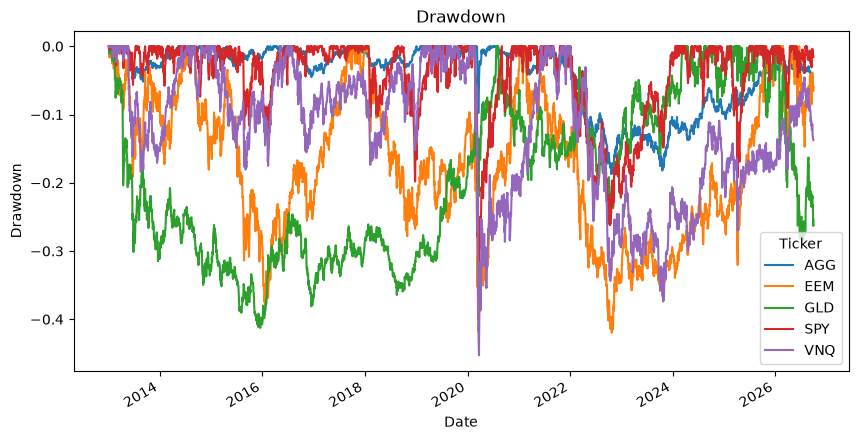

In [13]:
dd = risk.drawdown_series(returns)
dd.plot(figsize=(10, 5), title="Drawdown")
plt.ylabel("Drawdown")
plt.show()

### 3.2 Rolling volatility

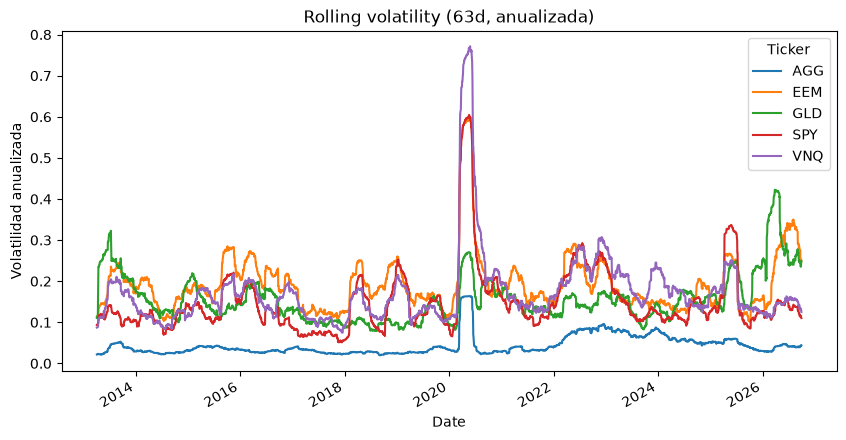

In [14]:
roll_vol = risk.rolling_volatility(returns, window=63, periods_per_year=PERIODS_PER_YEAR)
roll_vol.plot(figsize=(10, 5), title="Rolling volatility (63d, anualizada)")
plt.ylabel("Volatilidad anualizada")
plt.show()

### 3.3 Histograma de retornos con VaR y CVaR al 95%

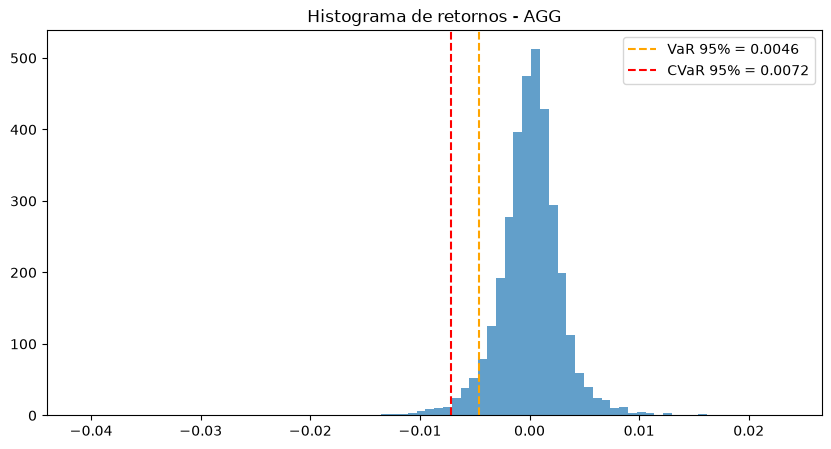

In [15]:
# TODO: repetir para cada activo/cartera, o iterar sobre returns.columns
asset = returns.columns[0]
series = returns[asset]

var_95 = risk.var_historical(series, level=0.95)
cvar_95 = risk.cvar_historical(series, level=0.95)

plt.figure(figsize=(10, 5))
plt.hist(series, bins=80, alpha=0.7)
plt.axvline(-var_95, color="orange", linestyle="--", label=f"VaR 95% = {var_95:.4f}")
plt.axvline(-cvar_95, color="red", linestyle="--", label=f"CVaR 95% = {cvar_95:.4f}")
plt.title(f"Histograma de retornos - {asset}")
plt.legend()
plt.show()

## 4. Preguntas

**Ahora mismo os dan 1M€. ¿Os convence alguna cartera? ¿Cuál y por qué?**

SPY por su mejor rentabilidad, Sharpe, Sortino y Calmar. Aun así habrá que gestionar el riesgo ya que vemos un Max Drawdown bastante alto (34%), convendra diversificar en al menos otra cartera con poca correlación y más estable.

**¿Qué activo tiene el peor perfil de cola y por qué no se aprecia mirando solo la volatilidad?**

VNQ sin dudarlo, si observamos tiene la skewness más negativa (-1,48), la mayor curtosis (25,9) y el peor max drawdown (-45,3%).

**¿Coincide el ranking por Sharpe con el ranking por Calmar?**

Si coincide pero miden cosas distintas.
Sharpe --> Penaliza Volatilidad diaria
Calmar --> Peor caida acumulada

**¿Cómo se comporta el VaR paramétrico en dos periodos diferentes?**

El VaR paramétrico no es estable: como es función directa de la media y la volatilidad estimadas, cambia mucho según el régimen de mercado. En 2017 (baja volatilidad), el VaR 95% de [activo] era X%, mientras que en febrero-junio de 2020 subió a Y%, unas N veces más

**¿Qué nos dice la métrica que habéis creado?**

Devuelve la fracción de periodos en que el drawdown es peor que threshold, que por defecto es -10 %.Mide, rango de 0 a 1 y que cuanto más bajo, mejor.